<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 05 · Identification, Inference, and Forecast Discipline</h1>
<p style="font-size:17px;margin-bottom:0">Prediction, causal identification, and valid inference are separated by design.</p>
</div>

**Research question.** Why can a precisely estimated regression be economically wrong, why can a valid instrument be nearly useless, and why can in-sample significance fail out of sample?

**Design.** Controlled simulations establish causal pathologies; real Fama–French factors test recursive forecast performance against a historical-mean benchmark.

## 1. Omitted-variable bias is a probability limit

Suppose the structural equation is

$$y=\beta x+\gamma z+u,\qquad \mathbb E[u\mid x,z]=0.$$

Regressing $y$ only on $x$ gives

$$\operatorname{plim}\widehat\beta_{short}=\beta+\gamma\frac{\operatorname{Cov}(x,z)}{\operatorname{Var}(x)}.$$

More observations shrink sampling uncertainty around this biased limit; they do not restore identification.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def find_root():
    here=Path.cwd().resolve()
    for candidate in (here,*here.parents):
        if (candidate/'projects'/'factor_allocation'/'output'/'monthly_factors.csv').exists():
            return candidate
    raise FileNotFoundError('Factor output not found')

ROOT=find_root(); OUT=ROOT/'projects'/'factor_allocation'/'output'
factors=pd.read_csv(OUT/'monthly_factors.csv',index_col='date',parse_dates=True)
FACTORS=['Mkt-RF','SMB','HML','RMW','CMA','Mom']
plt.style.use('seaborn-v0_8-whitegrid')
NAVY,BLUE,GOLD,RED,GREEN='#071B33','#1676B8','#C99700','#C84C4C','#26866A'
pd.options.display.float_format='{:,.4f}'.format
SEED=20260828

rng=np.random.default_rng(SEED)
n=2500; rho=.70; beta=1.0; gamma=1.5
x=rng.normal(size=n)
z=rho*x+np.sqrt(1-rho**2)*rng.normal(size=n)
y=beta*x+gamma*z+rng.normal(size=n)
short=sm.OLS(y,sm.add_constant(x)).fit()
long=sm.OLS(y,sm.add_constant(np.column_stack([x,z]))).fit()
theoretical=beta+gamma*np.cov(x,z,ddof=0)[0,1]/np.var(x)
display(pd.DataFrame({
    'estimate':[short.params[1],long.params[1],theoretical],
    'standard_error':[short.bse[1],long.bse[1],np.nan]
},index=['Short regression','Correctly controlled','OVB probability-limit approximation']))

,estimate,standard_error
Short regression,2.0585,0.0296
Correctly controlled,0.9766,0.0285
OVB probability-limit approximation,2.0497,NaN


## 2. Instrumental variables: validity is not strength

With endogenous $x$, an instrument $q$ identifies $\beta$ if $\operatorname{Cov}(q,u)=0$ and $\operatorname{Cov}(q,x)\neq0$. The just-identified estimator is

$$\widehat\beta_{IV}=\frac{\widehat{\operatorname{Cov}}(q,y)}{\widehat{\operatorname{Cov}}(q,x)}.$$

When the first-stage denominator is near zero, the estimator has a heavy-tailed finite-sample distribution. Exogeneity alone does not guarantee useful inference.

,median_first_stage_F,median_OLS,median_IV,IV_q05,IV_q95,IV_RMSE
first_stage_pi,,,,,,
0.0500,0.7978,1.4789,1.1994,-2.1574,5.2071,9.2681
0.1000,3.2184,1.4779,1.0604,-1.2640,1.6822,9.0423
0.3000,30.3244,1.4540,1.0044,0.7167,1.2128,0.1561
0.8000,204.8476,1.3396,1.0021,0.9036,1.0862,0.0549


C:\Users\badre\AppData\Local\Temp\ipykernel_23336\3976476187.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([np.clip(draws[s],-3,5) for s in draws],labels=[str(s) for s in draws],showfliers=False)


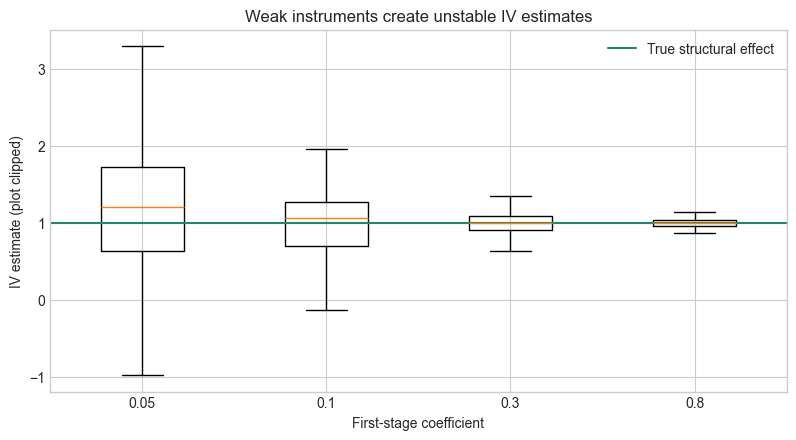

In [2]:
rng=np.random.default_rng(SEED+1)
records=[]; draws={}
for strength in [.05,.10,.30,.80]:
    iv_values=[]; ols_values=[]; first_f=[]
    for rep in range(500):
        q=rng.normal(size=500); u=rng.normal(size=500); v=rng.normal(size=500)
        x=strength*q+.75*u+v
        y=1.0*x+u
        q0=q-q.mean(); x0=x-x.mean(); y0=y-y.mean()
        iv_values.append((q0@y0)/(q0@x0))
        ols_values.append((x0@y0)/(x0@x0))
        fs=sm.OLS(x,sm.add_constant(q)).fit()
        first_f.append(float(fs.tvalues[1]**2))
    draws[strength]=np.asarray(iv_values)
    records.append({'first_stage_pi':strength,'median_first_stage_F':np.median(first_f),
                    'median_OLS':np.median(ols_values),'median_IV':np.median(iv_values),
                    'IV_q05':np.quantile(iv_values,.05),'IV_q95':np.quantile(iv_values,.95),
                    'IV_RMSE':np.sqrt(np.mean((np.asarray(iv_values)-1)**2))})
iv_table=pd.DataFrame(records).set_index('first_stage_pi')
display(iv_table)

fig,ax=plt.subplots(figsize=(9.5,4.7))
ax.boxplot([np.clip(draws[s],-3,5) for s in draws],labels=[str(s) for s in draws],showfliers=False)
ax.axhline(1,color=GREEN,linewidth=1.5,label='True structural effect')
ax.set(title='Weak instruments create unstable IV estimates',xlabel='First-stage coefficient',ylabel='IV estimate (plot clipped)')
ax.legend(frameon=False); plt.show()

## 3. Overlapping returns require dependence-robust inference

A 12-month forward return shares eleven monthly observations with the next 12-month return. Even if monthly innovations were independent, regression residuals are mechanically autocorrelated. OLS coefficients remain the same, but iid standard errors are not appropriate. Newey–West/HAC inference estimates the long-run covariance.

In [3]:
market=factors['Mkt-RF'].to_numpy()
forward=np.full(len(market),np.nan)
for t in range(len(market)-12):
    forward[t]=market[t+1:t+13].sum()
overlap=pd.DataFrame({'forward_12m':forward,'HML':factors.HML.to_numpy(),
                      'Mom':factors.Mom.to_numpy()},index=factors.index).dropna()
fit=sm.OLS(overlap.forward_12m,sm.add_constant(overlap[['HML','Mom']])).fit()
hac=fit.get_robustcov_results(cov_type='HAC',maxlags=11)
inference=pd.DataFrame({
    'coefficient':fit.params,
    'iid_standard_error':fit.bse,
    'HAC_standard_error':hac.bse,
    'iid_p_value':fit.pvalues,
    'HAC_p_value':hac.pvalues
},index=fit.params.index)
display(inference)
print(f'Durbin–Watson statistic on overlapping-regression residuals: {sm.stats.durbin_watson(fit.resid):.3f}')

,coefficient,iid_standard_error,HAC_standard_error,iid_p_value,HAC_p_value
const,0.0751,0.0059,0.0159,0.0000,0.0000
HML,-0.6169,0.1988,0.2845,0.0020,0.0304
Mom,-0.4445,0.1413,0.1606,0.0017,0.0058


Durbin–Watson statistic on overlapping-regression residuals: 0.218


## 4. Recursive forecasting and the historical-mean hurdle

For one-month-ahead market excess returns, predictors observed at $t$ forecast $r_{t+1}$. Every regression below is refitted using an expanding window. Forecasts are compared with the training-sample historical mean using

$$R^2_{OS}=1-\frac{\sum_t(r_{t+1}-\widehat r_{t+1|t})^2}{\sum_t(r_{t+1}-\bar r_{t|t})^2}.$$

A negative value means the predictive model loses to the mean out of sample, regardless of in-sample stories.

,OOS_R2,RMSE,forecast_correlation
model,,,
CMA,0.0031,0.0459,0.0560
HML,-0.0003,0.0460,0.0176
SMB,-0.0016,0.0460,0.0200
RMW,-0.0028,0.0461,-0.0074
Mom,-0.0049,0.0461,-0.0610
Mkt-RF,-0.0059,0.0461,-0.0066
All six factors,-0.0248,0.0466,-0.0354


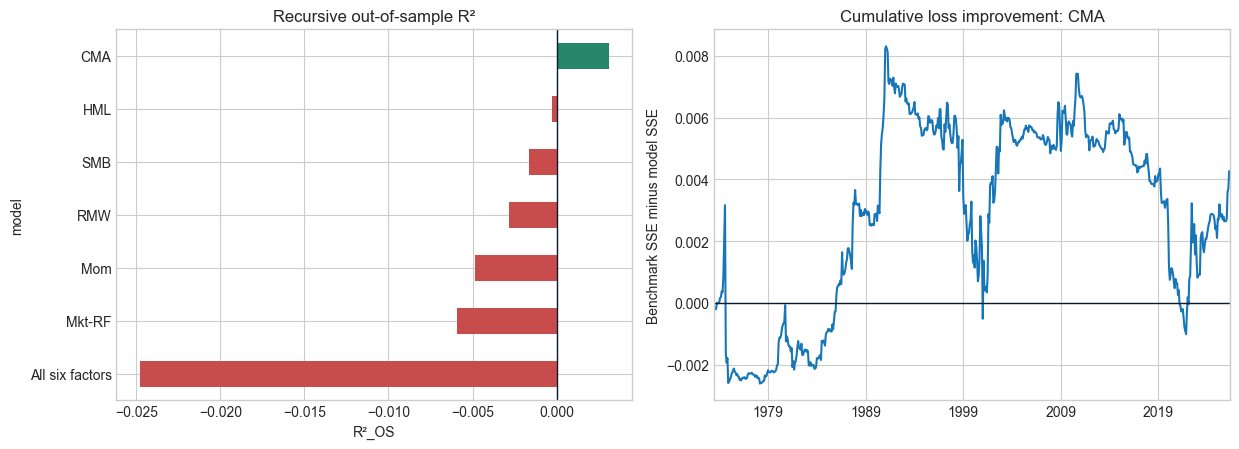

In [4]:
data=factors[FACTORS].copy()
data['target']=factors['Mkt-RF'].shift(-1)
data=data.dropna()

def recursive_forecast(columns,min_train=120):
    predictions=[]; benchmarks=[]; actual=[]; dates=[]
    X=data[columns].to_numpy(); y=data.target.to_numpy()
    for t in range(min_train,len(data)):
        x_train=X[:t]; y_train=y[:t]
        mean=x_train.mean(axis=0); scale=x_train.std(axis=0,ddof=1)
        z_train=(x_train-mean)/scale; z_test=(X[t]-mean)/scale
        design=np.column_stack([np.ones(t),z_train])
        coef=np.linalg.lstsq(design,y_train,rcond=None)[0]
        predictions.append(np.r_[1,z_test]@coef)
        benchmarks.append(y_train.mean()); actual.append(y[t]); dates.append(data.index[t])
    return pd.DataFrame({'actual':actual,'model':predictions,'historical_mean':benchmarks},index=dates)

specifications={name:[name] for name in FACTORS}
specifications['All six factors']=FACTORS
forecast_rows=[]; paths={}
for name,columns in specifications.items():
    result=recursive_forecast(columns); paths[name]=result
    sse_model=np.sum((result.actual-result.model)**2)
    sse_mean=np.sum((result.actual-result.historical_mean)**2)
    forecast_rows.append({'model':name,'OOS_R2':1-sse_model/sse_mean,
                          'RMSE':np.sqrt(sse_model/len(result)),
                          'forecast_correlation':result.actual.corr(result.model)})
forecast_table=pd.DataFrame(forecast_rows).set_index('model').sort_values('OOS_R2',ascending=False)
display(forecast_table)

best=forecast_table.index[0]; path=paths[best]
loss_difference=(path.actual-path.historical_mean)**2-(path.actual-path.model)**2
fig,axes=plt.subplots(1,2,figsize=(12.5,4.6))
forecast_table.OOS_R2.sort_values().plot.barh(ax=axes[0],color=[GREEN if x>0 else RED for x in forecast_table.OOS_R2.sort_values()])
axes[0].axvline(0,color=NAVY,linewidth=1); axes[0].set(title='Recursive out-of-sample R²',xlabel='R²_OS')
loss_difference.cumsum().plot(ax=axes[1],color=BLUE)
axes[1].axhline(0,color=NAVY,linewidth=1); axes[1].set(title=f'Cumulative loss improvement: {best}',ylabel='Benchmark SSE minus model SSE',xlabel='')
plt.tight_layout(); plt.show()

## 5. Research conclusion and model-risk register

- Omitted-variable bias is an identification failure. Large samples can make the wrong estimand look highly precise.
- IV validity and IV strength are separate requirements. Weak first stages create unstable, non-Gaussian estimates.
- Overlapping outcomes invalidate iid standard errors; HAC changes inference, not the coefficient or the research design.
- Predictive regressions must face recursive out-of-sample benchmarks. Trying several predictors and reporting only the winner creates a second layer of selection bias.

> **Boundary of the evidence.** The factor exercise is a forecast comparison, not a causal model of expected returns. OOS R² from one historical sample remains uncertain and the factor data are revised research portfolios.

### Extensions

1. Implement weak-IV robust Anderson–Rubin confidence sets.
2. Compare expanding and rolling windows under a known structural break.
3. Apply Clark–West inference when the predictive model nests the historical mean.
4. Control the false-discovery rate across a larger predictor library and retain a final untouched test period.